# Stage 1 — structural thickness probe
A nested ridge probe tests whether held-out subject embeddings contain structural information. Scaling and alpha selection use training subjects only.

In [1]:
from pathlib import Path
import os, subprocess, sys
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
SRC_DIR = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
SUBPROCESS_ENV = os.environ.copy()
SUBPROCESS_ENV['PYTHONPATH'] = str(SRC_DIR) + os.pathsep + SUBPROCESS_ENV.get('PYTHONPATH', '')
FEATURE_GLOB = 'artifacts/stage1/*/relat_cons_32/subject_features_all_op.npz'
METADATA_CSV = Path('data/raw/stage1/temp_metadata_v2.csv')
OUTPUT_DIR = Path('results/tables/stage1/structure_probe_32')

## Run the probe
The module writes only PNG figures plus the held-out predictions and compact metric summaries needed for the thesis.

In [2]:
subprocess.run([sys.executable, '-m', 'subject_nirs.stage1.probe', '--feature_glob', FEATURE_GLOB, '--feature_key', 'latent_raw', '--metadata_csv', str(METADATA_CSV), '--output_dir', str(OUTPUT_DIR), '--plot_format', 'png'], cwd=ROOT, env=SUBPROCESS_ENV, check=True)

Loaded metadata: (154, 3) (scalp, skull, csf)
Matched 154 feature fold(s)
Feature key: latent_raw
Refit selected probe on train+val: True
[001/154] test_id=  0 alpha=0.3 val_std_RMSE=0.7506 true=[3.8345 4.6382 2.5704] pred=[3.4123 5.559  3.3875]
[002/154] test_id=  1 alpha=0.3 val_std_RMSE=0.7979 true=[2.79   4.879  4.1314] pred=[3.8483 4.1425 4.0793]
[003/154] test_id= 10 alpha=3 val_std_RMSE=1.1005 true=[3.2216 5.9378 3.9927] pred=[3.0677 5.3481 4.1345]
[004/154] test_id=100 alpha=1 val_std_RMSE=0.7782 true=[4.5561 6.9474 3.6644] pred=[4.5136 7.2433 3.5846]
[005/154] test_id=101 alpha=0.03 val_std_RMSE=0.8265 true=[4.0538 7.2983 3.5569] pred=[4.6224 6.6876 3.7129]
[006/154] test_id=102 alpha=0.0001 val_std_RMSE=0.6635 true=[4.2618 6.1359 3.6141] pred=[3.1416 7.6894 1.8444]
[007/154] test_id=103 alpha=0.3 val_std_RMSE=0.6349 true=[4.5561 5.8417 5.1919] pred=[4.0564 6.7531 4.6526]
[008/154] test_id=104 alpha=3 val_std_RMSE=0.8312 true=[3.4797 7.083  6.9351] pred=[3.8394 5.1377 5.4338]


CompletedProcess(args=['/home/md703/.conda/envs/yc_ae/bin/python', '-m', 'subject_nirs.stage1.probe', '--feature_glob', 'artifacts/stage1/*/relat_cons_32/subject_features_all_op.npz', '--feature_key', 'latent_raw', '--metadata_csv', 'data/raw/stage1/temp_metadata_v2.csv', '--output_dir', 'results/tables/stage1/structure_probe_32', '--plot_format', 'png'], returncode=0)

,target,n_test_subjects,probe_mae,baseline_mae,mae_improvement,probe_rmse,baseline_rmse,probe_r2,probe_pearson_r,probe_spearman_rho
0,scalp,154,0.649020,0.637343,-0.011676,0.838825,0.843474,-0.001978,0.202132,0.243943
1,skull,154,0.913621,1.217686,0.304065,1.170558,1.504753,0.386924,0.622667,0.623342
2,csf,154,0.815232,1.020787,0.205555,1.120059,1.322286,0.273075,0.533829,0.595261


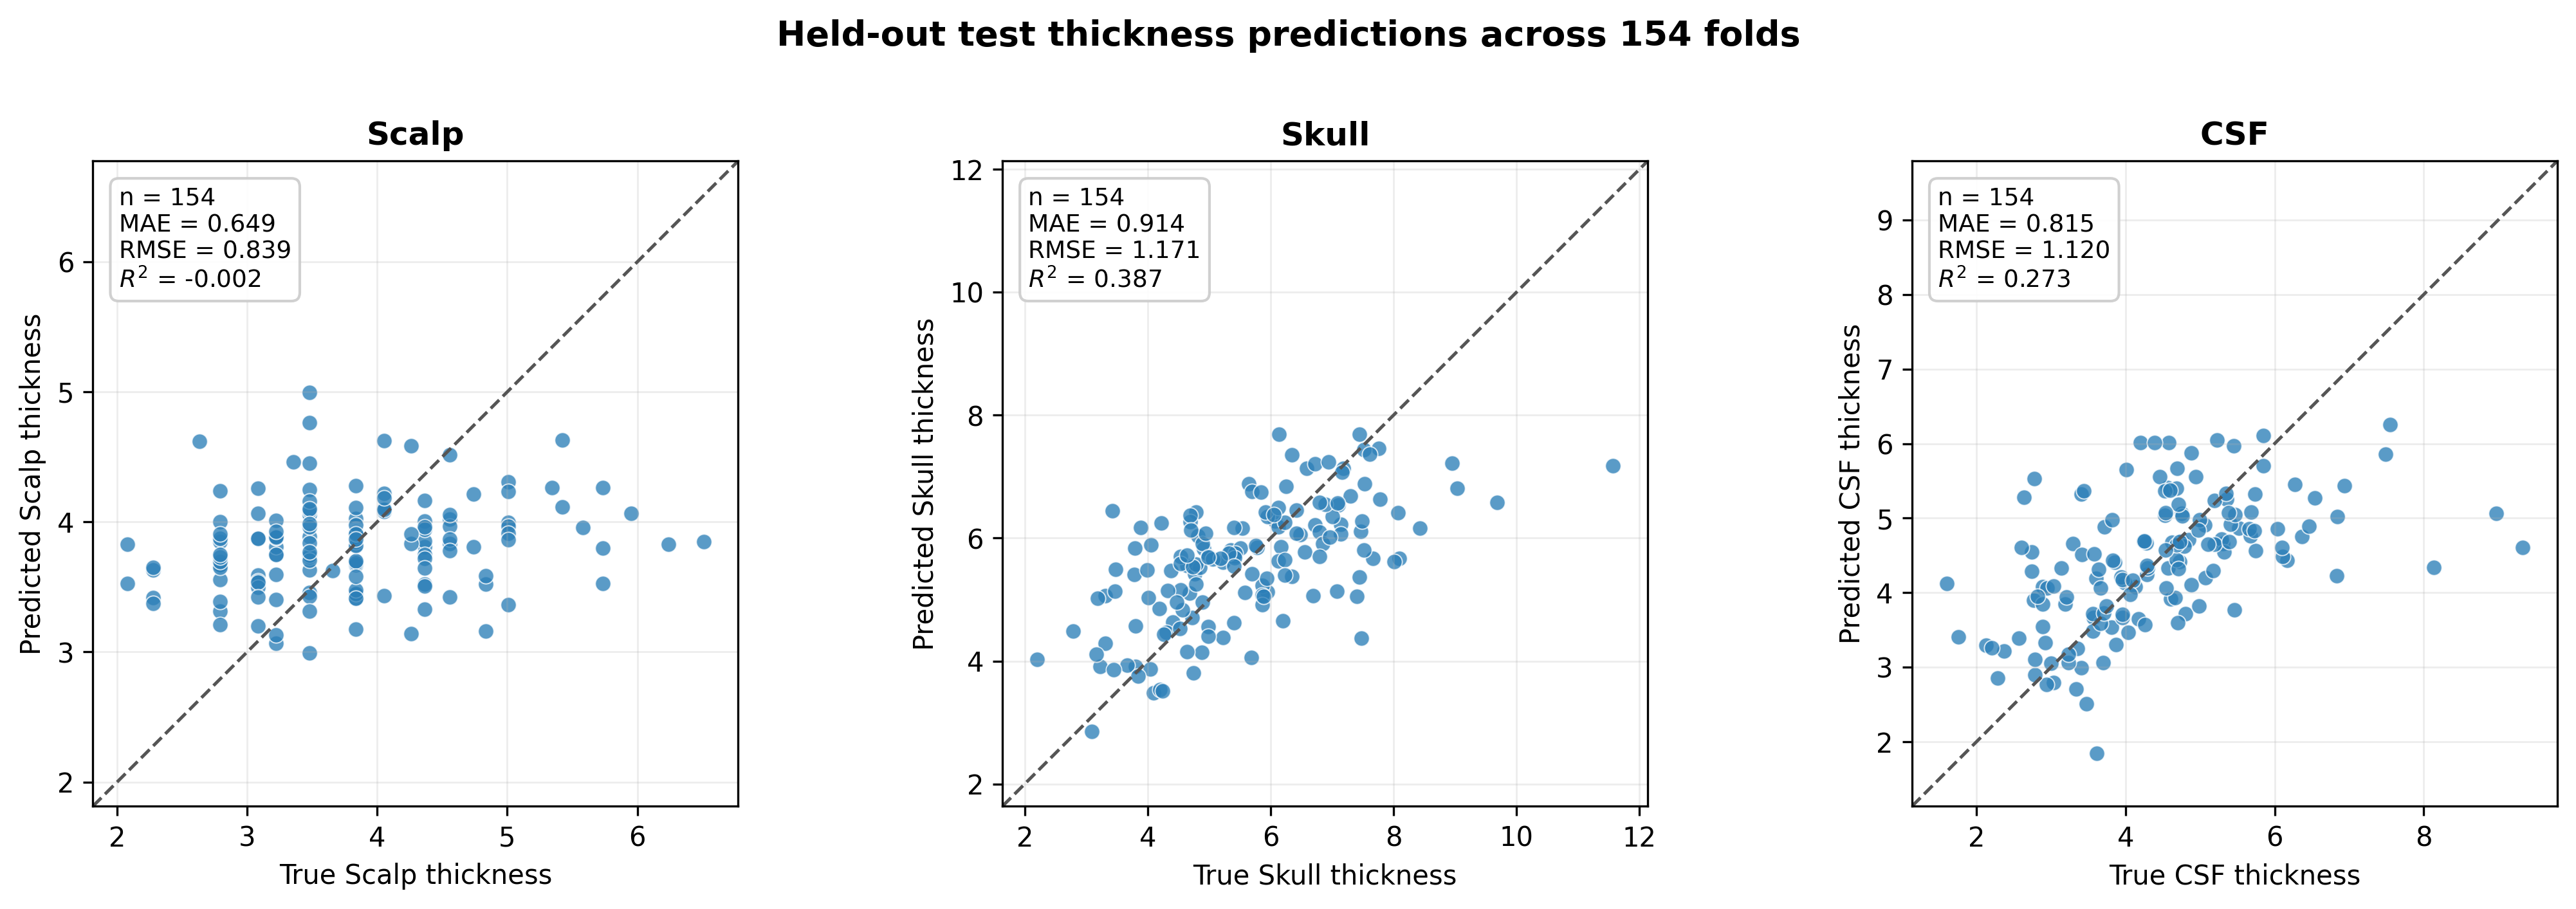

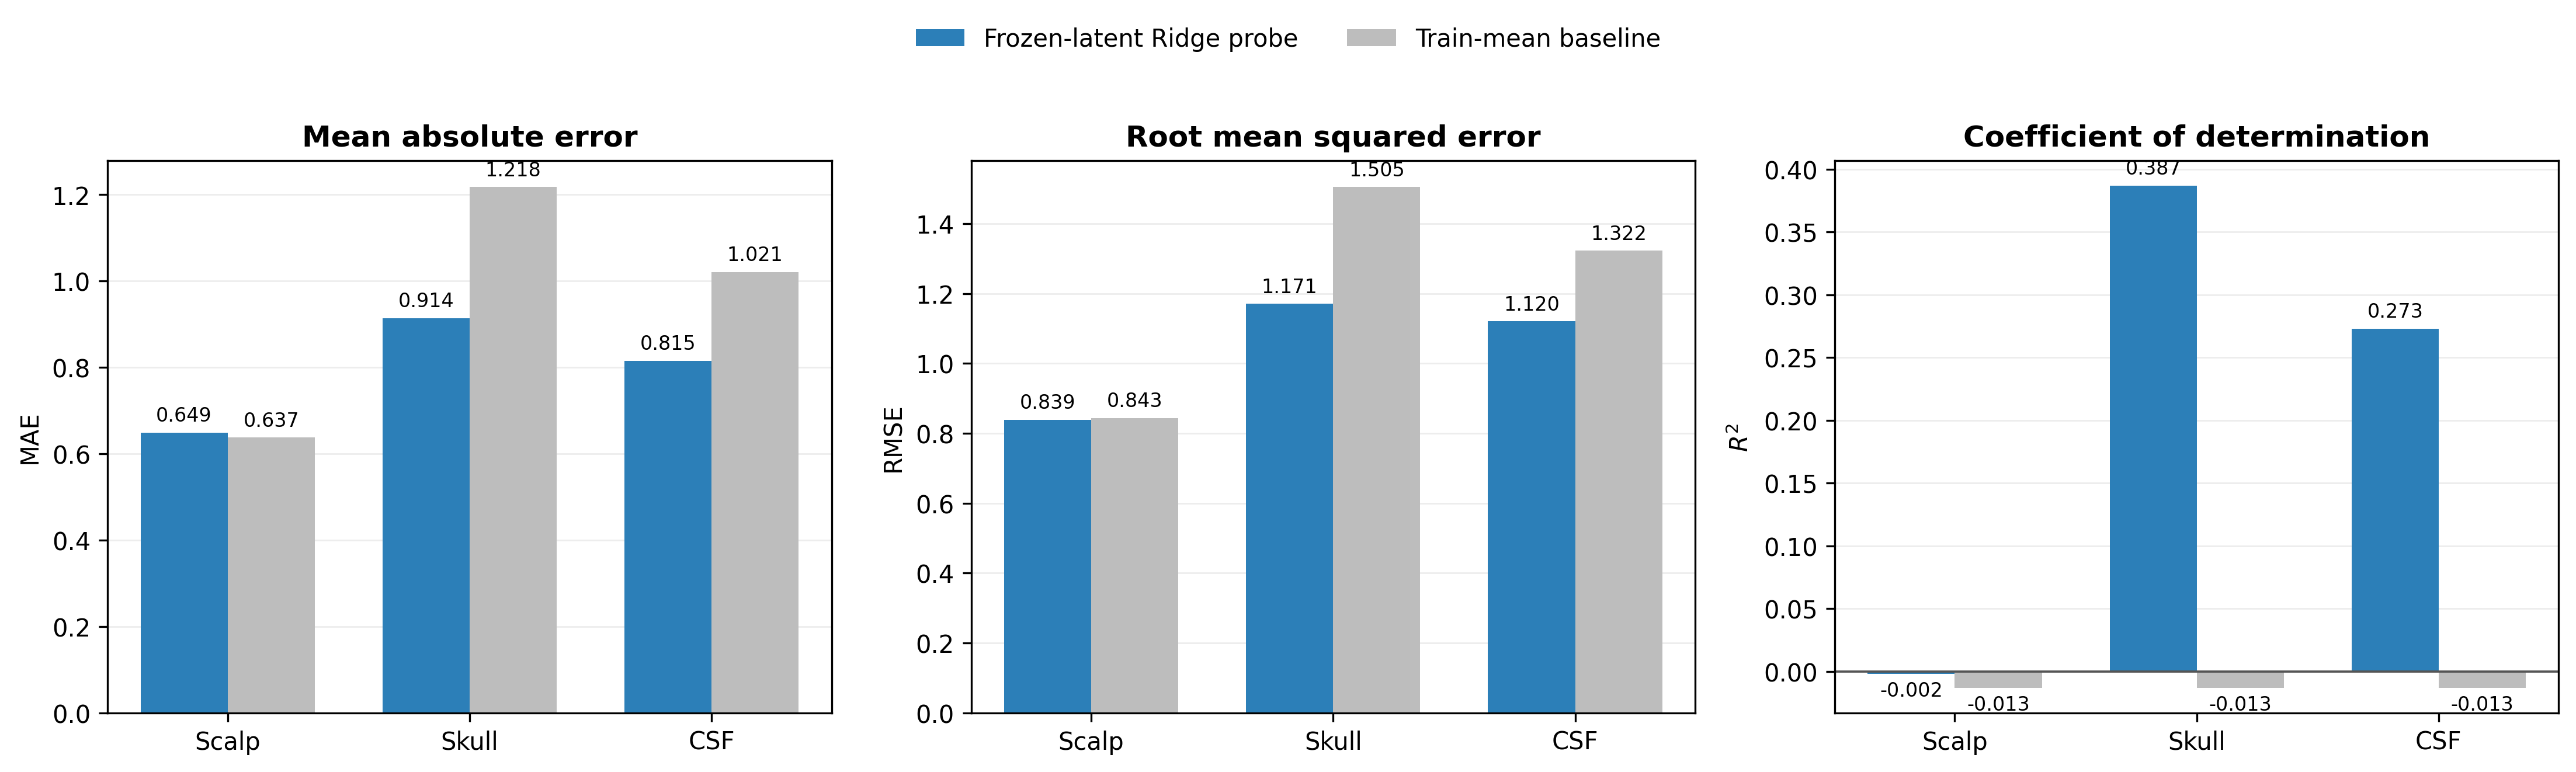

In [3]:
import pandas as pd
from IPython.display import Image, display

display(pd.read_csv(OUTPUT_DIR / 'summary.csv'))
for figure_path in sorted(OUTPUT_DIR.glob('*.png')):
    display(Image(filename=str(figure_path), width=1100))
